# 00 - Baseline Setup and Sanity Checks

This notebook checks the baseline experiment folder and summarizes the short
sanity runs. The baseline stage was the first project pass before the longer
documented benchmark workflow.

What this notebook does:

- records package versions
- confirms the MuJoCo environments load
- displays the saved sanity-check results
- audits baseline result and figure artifacts


## Load baseline paths

This cell finds the baseline folder and defines shared paths.


In [1]:
from pathlib import Path
import os, sys, time

def find_baseline_root():
    start = Path.cwd().resolve()
    for base in [start, *start.parents]:
        for candidate in [base, base / "baseline", base / "MuJoCo_RL_Project_Final_Submission" / "baseline"]:
            if (candidate / "baseline_summary.md").exists() and (candidate / "results").exists():
                return candidate.resolve()
    raise RuntimeError("Could not locate baseline folder")

BASE_DIR = find_baseline_root()
os.chdir(BASE_DIR)
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

RAW_DIR = BASE_DIR / "results" / "raw"
PROC_DIR = BASE_DIR / "results" / "processed"
FINAL_DIR = BASE_DIR / "results" / "final"
FIG_DIR = BASE_DIR / "figures"
REPORT_FIG_DIR = FIG_DIR / "report_ready"
for folder in [RAW_DIR, PROC_DIR, FINAL_DIR, REPORT_FIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

ENV_IDS = ["HalfCheetah-v5", "Hopper-v5", "Walker2d-v5"]
ALGORITHMS = ["PPO", "SAC", "TD3", "DDPG", "TQC"]
print(f"Baseline root: {BASE_DIR}")
print(f"Python: {sys.executable}")


Baseline root: D:\MuJoCo_RL_Project\MuJoCo_RL_Project_Final_Submission\baseline
Python: C:\Users\digilians01\.conda\envs\RL_PROJECT\python.exe


## Package versions

These versions describe the environment used to run the baseline notebooks.


In [2]:
import importlib, platform
packages = [
    "gymnasium", "mujoco", "stable_baselines3", "sb3_contrib",
    "torch", "numpy", "pandas", "matplotlib", "scipy", "seaborn"
]
rows = []
for package in packages:
    try:
        module = importlib.import_module(package)
        version = getattr(module, "__version__", "installed")
    except Exception as exc:
        version = f"missing: {exc}"
    rows.append({"package": package, "version": version})
print(platform.platform())
display(pd.DataFrame(rows))


Windows-10-10.0.26200-SP0


,package,version
0,gymnasium,1.3.0
1,mujoco,3.10.0
2,stable_baselines3,2.9.0
3,sb3_contrib,2.9.0
4,torch,2.12.1+cu126
5,numpy,2.2.5
6,pandas,2.3.3
7,matplotlib,3.10.9
8,scipy,1.15.3
9,seaborn,0.13.2


## Environment check

Create each MuJoCo task and record its spaces.


In [3]:
import gymnasium as gym
rows = []
for env_id in ENV_IDS:
    env = gym.make(env_id)
    rows.append({
        "environment": env_id,
        "observation_shape": env.observation_space.shape,
        "action_shape": env.action_space.shape,
        "max_episode_steps": getattr(env.spec, "max_episode_steps", None),
    })
    env.close()
display(pd.DataFrame(rows))


,environment,observation_shape,action_shape,max_episode_steps
0,HalfCheetah-v5,"(17,)","(6,)",1000
1,Hopper-v5,"(11,)","(3,)",1000
2,Walker2d-v5,"(17,)","(6,)",1000


## Sanity-check output

This 5k-step run confirms that the baseline training loop worked.


In [4]:
sanity_path = RAW_DIR / "sanity_check.csv"
sanity_df = pd.read_csv(sanity_path) if sanity_path.exists() else pd.DataFrame()
print(f"Loaded rows: {len(sanity_df)}")
display(sanity_df)


Loaded rows: 15


,environment,algorithm,seed,timesteps,mean_reward,std_reward,wall_clock_seconds,status
0,HalfCheetah-v5,PPO,42,5000,-1.328490,0.503407,9.02,OK
1,HalfCheetah-v5,SAC,42,5000,-68.790270,3.377476,37.45,OK
2,HalfCheetah-v5,TD3,42,5000,-295.825657,16.582914,18.96,OK
3,HalfCheetah-v5,DDPG,42,5000,-430.597066,55.182137,19.92,OK
4,HalfCheetah-v5,TQC,42,5000,-129.368177,24.998664,39.73,OK
5,Hopper-v5,PPO,42,5000,54.692899,0.173670,10.07,OK
6,Hopper-v5,SAC,42,5000,184.683655,0.296152,37.83,OK
7,Hopper-v5,TD3,42,5000,89.116621,1.195370,19.00,OK
8,Hopper-v5,DDPG,42,5000,2.668759,0.079866,19.39,OK
9,Hopper-v5,TQC,42,5000,254.407411,0.864954,37.02,OK


## Sanity plot

This is a quick smoke-test plot, not a final benchmark figure.


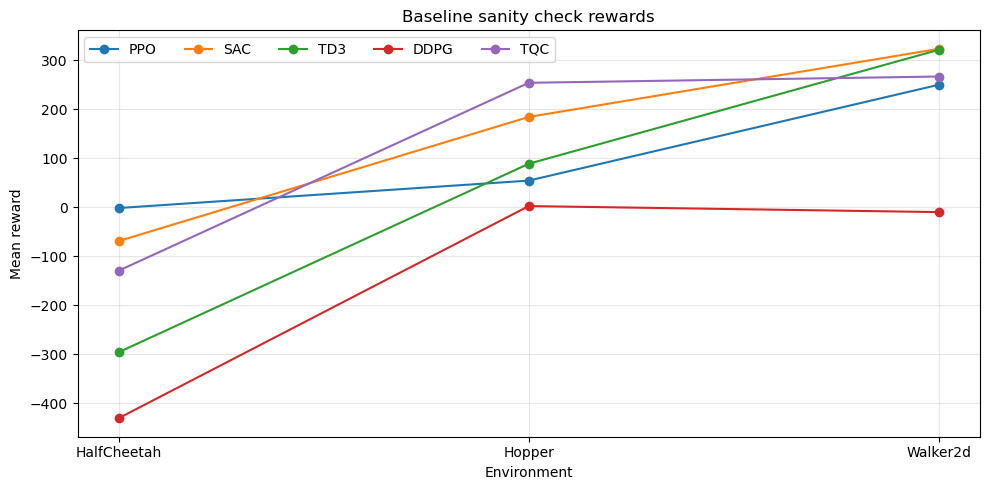

In [5]:
if not sanity_df.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    for algo in ALGORITHMS:
        part = sanity_df[sanity_df["algorithm"] == algo]
        ax.plot(part["environment"].str.replace("-v5", "", regex=False),
                part["mean_reward"], marker="o", label=algo)
    ax.set_title("Baseline sanity check rewards")
    ax.set_xlabel("Environment")
    ax.set_ylabel("Mean reward")
    ax.grid(alpha=0.3)
    ax.legend(ncol=5)
    plt.tight_layout()
    plt.show()


## Artifact inventory

Large model files are generated locally by the training notebooks.


In [6]:
rows = []
for folder in ["notebooks", "results", "figures", "baseline_summary"]:
    path = BASE_DIR / folder
    files = [p for p in path.rglob("*") if p.is_file()] if path.exists() else []
    rows.append({
        "folder": folder,
        "files": len(files),
        "size_mb": round(sum(p.stat().st_size for p in files) / 1024**2, 3),
    })
display(pd.DataFrame(rows))


,folder,files,size_mb
0,notebooks,8,0.083
1,results,24,2.157
2,figures,26,2.210
3,baseline_summary,32,1.608
